# ECE1508: Deep Generative Models -- SUM26
## Assignment 1: Text Generation and Language Models
## Question 3: Basic Context Aware LMs
### General Overview
In this question, we implement basic context-aware LMs. Please refer to Question 3 in Assignment 1.

### How to Answer?
Please complete all parts noted by `#COMPLETE`. Note that these parts are at both __Code__ and __Markdown.__


#### Let's start with loading necessary libraries.

In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F

### Data
We train this model on the attached tiny text file named `corpus.txt`. We first load the corpus as a list of characters named `corpus`.

In [2]:
filename = "corpus.txt"

# COMPLETE
## Read corpus as a list of characters
## Name the read list `corpus`
with open(filename, 'r') as f:
    corpus = list(f.read())

Let's play around with the corpus to see what there is.

In [3]:
print(len(corpus))
print(corpus[:150])

212623
['L', 'e', 't', "'", 's', ' ', 't', 'r', 'y', ' ', 's', 'o', 'm', 'e', 't', 'h', 'i', 'n', 'g', '.', '\n', 'I', ' ', 'h', 'a', 'v', 'e', ' ', 't', 'o', ' ', 'g', 'o', ' ', 't', 'o', ' ', 's', 'l', 'e', 'e', 'p', '.', '\n', 'T', 'o', 'd', 'a', 'y', ' ', 'i', 's', ' ', 'J', 'u', 'n', 'e', ' ', '1', '8', 't', 'h', ' ', 'a', 'n', 'd', ' ', 'i', 't', ' ', 'i', 's', ' ', 'M', 'u', 'i', 'r', 'i', 'e', 'l', "'", 's', ' ', 'b', 'i', 'r', 't', 'h', 'd', 'a', 'y', '!', '\n', 'M', 'u', 'i', 'r', 'i', 'e', 'l', ' ', 'i', 's', ' ', '2', '0', ' ', 'n', 'o', 'w', '.', '\n', 'T', 'h', 'e', ' ', 'p', 'a', 's', 's', 'w', 'o', 'r', 'd', ' ', 'i', 's', ' ', '"', 'M', 'u', 'i', 'r', 'i', 'e', 'l', '"', '.', '\n', 'I', ' ', 'w', 'i', 'l', 'l', ' ', 'b', 'e', ' ', 'b']


### Tokenization
For tokenization, we use a character level tokenization. This means that each character is a single token. To this end, we make a vocabulary of all available characters in the corpus and implement the `encode` and `decode` functions, which convert a text to index sequence and vice versa. 

In [4]:
# COMPLETE
## make a list including all characters in the corpus
## name it `vocab``
## print the number of characters, i.e., `len(vocab)`
vocab = list(set(corpus))
print(len(vocab))


84


In [5]:
# Write encode and decode function
char_to_token = {char:idx for idx,char in enumerate(vocab)}
token_to_char = {idx:char for idx,char in enumerate(vocab)}

# encode = # COMPLETE
## encode converts a text to token indices
def encode(text):
    return [char_to_token[char] for char in text]

# decode = # COMPLETE
## decode converts a token sequence to text
def decode(token_sequence):
    return ''.join([token_to_char[token] for token in token_sequence])

Let's try an example to confirm the implementation.

In [6]:
text = 'this is the first Assignment!'

# convert to token seq
x = encode(text)
print(x)

# convert back to text
text_dec = decode(x)
print(text_dec)

[8, 56, 2, 50, 1, 2, 50, 1, 8, 56, 47, 1, 13, 2, 78, 50, 8, 1, 7, 50, 50, 2, 45, 19, 63, 47, 19, 8, 36]
this is the first Assignment!


### Make batch of sequences
We next implement a function that makes a batch of text sequences. 

In [7]:
import random

# This function makes a random batch of size B, each sample being of length T
def get_batch(dataset, batch_size, seq_len, device):
    '''
    dataset: encoded text
    batch_size: B
    seq_len: T+1
    device: we will choose "mps", "cuda" or "cpu"
    '''

    # make sure we do not choose a start point with less that T+1 tokens to the end
    # max_start = # COMPLETE
    max_start = len(dataset) - seq_len


    # initial empty batch
    samples = []

    # make a batch
    for _ in range(batch_size):
        # start_idx = # COMPLETE
        start_idx = random.randint(0, max_start) # inclusive on both ends 
        # seq = # COMPLETE  # sample a seq of length T+1
        seq = dataset[start_idx:start_idx + seq_len]
        # COMPLETE #append to `samples`
        samples.append(seq)
    
    # convert to Tensor and move to selected device
    x = torch.tensor(samples, dtype=torch.long).to(device=device) 

    # it happens to make x torch.Size([32, 65, 1]) -> use .squeeze(-1)
    x = x.squeeze(-1)
    return x  # (B, T+1) # seq_len = T+1

### LM 1
In this architecture, to predict the next token, we build a context by __averaging__ the embeddings of all previous tokens, i.e., 

$$
\mathbf{c}_t = \frac{1}{t} \sum_{i=1}^t \mathbf{e}_i
$$

Assuming the embedding size to be `embd_size`, the MLP then use a linear layer to convert the context `c_t` of size `embd_size` to a logit vector of size `vocab_size`. The distribution of the next token is then set to be the softmax of the MLP output. 


### Implementing LM 1
We now implement the first architecture as illustrated in the question. Note that the implementation should take a __batch__ of sample texts as input.

In [8]:
class ContextAwareLM(nn.Module):
    def __init__(self, vocab_size, embd_size):
        super(ContextAwareLM, self).__init__()

        # Embedding layer: each embedding is of size (embd_size)
        # self.embedding = # COMPLETE
        self.embedding = nn.Embedding(vocab_size, embd_size) # each row is a token

        # Linear layer of MLP of size (embd_size, vocab_size)
        # self.MLP = # COMPLETE
        self.MLP = nn.Linear(embd_size, vocab_size)

    def forward(self, x):
        """
        x: Tensor of shape (B, T+1), where B is batch size and T+1 is length of sample.
        """

        # Compute B and T
        B, T_plus_1 = x.size() # x: (B, T+1)
        T = T_plus_1 - 1

        # Get token embeddings for input sequence
        # Apply Embedding. It should return objects of (B, T+1, embd_size)
        # embeddings = # COMPLETE  
        embeddings = self.embedding(x) # (B, T+1, embd_size)

        # Compute context at each time t=1,...,T
        ## You may find `torch.stack` useful
        # context = # COMPLETE
        context = torch.stack([
            embeddings[:, :t, :].mean(dim=1)
            for t in range(1, T_plus_1)
        ], dim=1)
        
        # Compute final logits before Softmax
        # logits = # COMPLETE  
        logits = self.MLP(context) # (B, T, vocab_size)
        
        return logits

### Train LM 1
We now implement the training loop. First, let's fix the parameters.

In [9]:
## Parameters 

# select a device that we want to shift the process on: cuda, cpu, mps
if torch.backends.mps.is_built():
    device = "mps"
elif torch.backends.cuda.is_built():
    device = "cuda"
else:
    device = "cpu"

# Batch parameters
B = 32            # Batch size
T = 64            # Sample length

# Embedding and vocab_size
embd_size = 128              # Embedding size
vocab_size = len(vocab)      # Vocab size

# Training loop parameters
learning_rate = 1e-3
num_iters = 1000

# Encode corpus to a dataset
# dataset = # COMPLETE # encode the whole corpus
dataset = encode(corpus)

import torch.optim as optim
# Model, loss, optimizer
model = ContextAwareLM(vocab_size, embd_size).to(device=device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
# criterion = # COMPLETE #choose right loss
criterion = nn.CrossEntropyLoss()

We now complete the training loop.

In [10]:
# we save the loss after every 100 iterations
log_interval = 100

# Training loop 
loss_history = []

for step in range(num_iters):
    model.train()

    # x = # COMPLETE  # get a batch of (B, T+1)
    x = get_batch(dataset, B, T+1, device)

    # logits = # COMPLETE     # pass through the model -> (B, T, vocab_size)
    logits = model(x)
    
    # targets = # COMPLETE    # make labels using next tokens in the sentence ->(B, T)
    targets = x[:, 1:]

    # loss = # COMPLETE # compute loss between logits and targets
    loss = criterion(logits.reshape(-1, vocab_size), targets.reshape(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % log_interval == 0:
        print(f"Step {step+1}: Loss = {loss.item():.4f}")
        loss_history.append(loss.item())

Step 1: Loss = 4.4776
Step 101: Loss = 3.0967
Step 201: Loss = 3.0427
Step 301: Loss = 3.0622
Step 401: Loss = 2.9818
Step 501: Loss = 3.0061
Step 601: Loss = 2.9830
Step 701: Loss = 2.9472
Step 801: Loss = 3.0169
Step 901: Loss = 2.9564


### Comparing to Maximum Entropy bound
The cross entropy is always upper-bounded by the maximum entropy of a single character which is 

$$
H(x_{t+1} \vert x_1, \ldots, x_t) \leq H(x_{t+1}) \leq \ln (\vert V \vert)
$$

Where $H$ is the entropy (information-theoretic metric), and $\vert V \vert$ denotes the `vocab_size`. We now plot the training curve and compare it to this upper bound. To this end, run the following code.

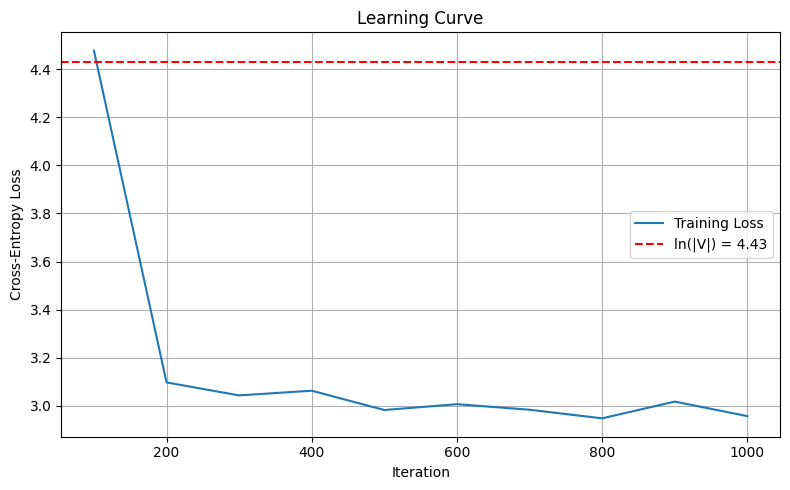

In [11]:
import matplotlib.pyplot as plt
import math

# Plotting learning curve
plt.figure(figsize=(8, 5))
plt.plot(range(log_interval, num_iters + 1, log_interval), loss_history, label="Training Loss")
upper_bound = math.log(vocab_size)
plt.axhline(upper_bound, color='red', linestyle='--', label=f"ln(|V|) = {upper_bound:.2f}")
plt.xlabel("Iteration")
plt.ylabel("Cross-Entropy Loss")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Question: _Explain your observation._

The upper bound (the red dashed line) corresponds to what a completely uniform predictor would produce. Given vocabulary size $|V|$, a uniform model predicts $p(x)=\frac{1}{|V|}$ for every token, and the cross entropy becomes $-\log(\frac{1}{|V|})=\ln(|V|)$. Therefore, $\ln(|V|)$ represents the “random guessing” baseline.

Our model effectively reduces the cross entropy loss throughout training. During the first 200 iterations, the loss drops sharply from approximately 4.4 to 3.1. Beyond that point, the loss continues to decrease (but in a steadier way). By the end of training (1000 iterations), the loss is just below 3.0, substantially lower than the random-guessing baseline of 4.43.

*(note: numbers are based on the training results from the first attempt. It may look different after re-running.)*

This indicates that the model has learned non-uniform structure and statistical patterns in the text data.

### Generating Text
We now write a Code that completes an incomplete text. At this point, we do a minor change: when we want to compute probabilities from the logits, we apply __temperature__ $\theta$ as follows

$$
P(x_{t+1} \vert c_t) = \mathrm{Softmax} ( \frac{\mathrm{logits}}{\theta} )
$$

By setting $\theta= 1$ this reduces to the basic generation. However, we can play with $\theta$ to increase or reduce the randomness of the sampled token. 

In [12]:
def generate_text(model, prompt, max_new_tokens, temperature = 1.0):
    '''
    model: trained LM
    prompt: incomplete text
    max_new_tokens: maximum new tokens generated by the model
    temperature: theta in the above formula
    '''
    model.eval()

    # Start with encoded prompt
    # context = # COMPLETE # encode text, truncate if needed
    context = encode(prompt)
    generated = context[:] # basically equivalent to .copy() 

    for _ in range(max_new_tokens):
        # make input to be a tensor
        x = torch.tensor(generated[-T:], dtype=torch.long, device=device).unsqueeze(0)

        # actual len = x.size(1) # x: (B,T+1)
        
        if x.size(1) < T + 1:
            # Pad with dummy tokens (e.g., zeros) to make size T+1
            # pad_len = # COMPLETE
            pad_len = (T+1) - x.size(1)
            # x = # COMPLETE #add dummy tokens to x ## you may use torch.cat
            x = torch.cat([x, torch.zeros((1, pad_len), dtype=torch.long, device=device)], dim=1)

        with torch.no_grad():
            # logits =# COMPLETE  # (1, T, vocab_size)
            logits = model(x)

            # next_token_logits = # COMPLETE  # get last logit
            
            # IMPORTANT:
            # logits has length T while input x has length T+1, 
            # plus the x may be padded with zeros
            # so the last valid timestep index should be x.size(1) - 2
            next_token_logits = logits[0, x.size(1) - 2, :]

            # Apply temperature
            # next_token_logits_with_temp = # COMPLETE
            next_token_logits_with_temp = next_token_logits / temperature

            # find distribution
            # probs = # COMPLETE
            probs = torch.softmax(next_token_logits_with_temp, dim=-1)

            # Sample from distribution
            # next_token = # COMPLETE
            next_token = torch.multinomial(probs, num_samples=1).item()


        generated.append(next_token)

    return decode(generated)


Let's now complete a text with only two characters.

In [13]:
prompt = "This is a book. The"
generate_text(model, prompt, 2, temperature=1)

'This is a book. The\n\n'

In [14]:
# temp = 1.5
generate_text(model, prompt, 2, temperature=1.5)

'This is a book. The\n\n'

In [15]:
# temp = 0.7
generate_text(model, prompt, 2, temperature=0.7)

'This is a book. The\n\n'

In [16]:
# temp = 0.2
generate_text(model, prompt, 2, temperature=0.2)

'This is a book. The\n\n'

### Question: _What do you conclude?_

The result from temp=1 (based on the first attempt) returns `'This is a book. Thek\n'`. It does not make much literal sense. Since the model samples from the probability distribution of the next token, the generated `'k'` is one possible continuation learned from the training data, followed by a line break. This also reflects the limitation of the relatively small character-level language model, which can learn local character patterns without necessarily generating semantically coherent text.

### Question: _Play with the temperature. What do you observe? What is your conclusion?_

With temp=1.5, the model predicts a line break immediately after the prompt. With temp=0.7, it predicts a capital `'T'` as the next character, while with temp=0.2, it again predicts a line break.

According to our model design, temperature is used as the denominator of the next-token logits before applying softmax. A higher temperature flattens the distribution, increasing randomness and making the generated text more diverse but potentially less coherent. Whereas a lower temperature would make the probability distribution sharper, causing the model to favour tokens that have high probability, thereby generating more deterministic outputs. 

### LM 2
We now use Self-Attention to build a context. For each time $t$, we compute key, query, and values as  

$$
\mathbf{k}_t =  \texttt{Linear} (\mathbf{e}_t), \qquad \mathbf{q}_t =  \texttt{Linear} (\mathbf{e}_t), \qquad \mathbf{v}_t =  \texttt{Linear} (\mathbf{e}_t),
$$

respectively. We set the keys, queries, and values to be of the embedding size `embd_size`. The context at time $t$ is then computed by the Self-Attention mechanism with Positional Encoding and Masked Decoding as we discussed in the course. We show the context at time $t$ with $\mathbf{c}_t$. In other words, we can say

$$
\mathbf{c}_t = \texttt{SelfAttention} (\mathbf{q}_t, \mathbf{k}_{1:t}, \mathbf{v}_{1:t}) 
$$

We use learnable positional encoding in this assignment, i.e., learnable embeddings trained jointly with the model (use `nn.Embedding`).

__Important:__ Please implement the self-attention mechanism as given in the course without adding any additional scaling or modification. 

Similar to LM 1, we use an MLP with a single linear layer to convert the context `c_t` of size `embd_size` to a logit vector of size `vocab_size`. The distribution of the next token is then set to be the softmax of the MLP output. 

### Implementing LM 2
We now implement this new architecture

In [17]:
class SA_LM(nn.Module):
    def __init__(self, vocab_size, embd_size):
        # self.pos_embedding = # COMPLETE
         # COMPLETE

        super(SA_LM, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embd_size)
        # Learnable positional embedding
        self.pos_embedding = nn.Embedding(T + 1, embd_size)

        self.key = nn.Linear(embd_size, embd_size)
        self.query = nn.Linear(embd_size, embd_size)
        self.value = nn.Linear(embd_size, embd_size)

        self.MLP = nn.Linear(embd_size, vocab_size)


    def forward(self, x):
        # COMPLETE  # (B, T, vocab_size)

        B, T_plus_1 = x.size()
        T = T_plus_1 - 1

        token_emb = self.embedding(x)  # (B, T+1, embd_size)

        positions = torch.arange(T_plus_1, device=x.device)
        pos_emb = self.pos_embedding(positions)  # (T+1, embd_size)

        embeddings = token_emb + pos_emb  # (B, T+1, embd_size)

        K = self.key(embeddings) # (B, T+1, embd_size)
        Q = self.query(embeddings) # (B, T+1, embd_size)
        V = self.value(embeddings) # (B, T+1, embd_size)

        contexts = []

        for t in range(1, T_plus_1):
            q_t = Q[:, t-1:t, :] # (B, 1, embd_size)
            k_past = K[:, :t, :] # (B, t, embd_size)
            v_past = V[:, :t, :] # (B, t, embd_size)

            scores = torch.bmm(q_t, k_past.transpose(1, 2)) # (B, 1, t)

            attn_weights = torch.softmax(scores, dim=-1) # (B, 1, t)

            c_t = torch.bmm(attn_weights, v_past) # (B, 1, embd_size)

            contexts.append(c_t.squeeze(1)) # (B, embd_size)

        context = torch.stack(contexts, dim=1) # (B, T, embd_size)

        logits = self.MLP(context) # (B, T, vocab_size)
        
        return logits

### Train LM 2
We now train this LM

In [18]:
## Parameters 

# select a device that we want to shift the process on: cuda, cpu, mps
if torch.backends.mps.is_built():
    device = "mps"
elif torch.backends.cuda.is_built():
    device = "cuda"
else:
    device = "cpu"

# Batch parameters
B = 32            # Batch size
T = 64            # Sample length

# Embedding and vocab_size
embd_size = 128              # Embedding size
vocab_size = len(vocab)      # Vocab size

# Training loop parameters
learning_rate = 1e-3
num_iters = 1000

# Encode corpus to a dataset
# dataset = # COMPLETE # encode the whole corpus 
# dataset = encode(corpus) # same as above and expect to be run already

import torch.optim as optim
# Model, loss, optimizer
# model = # COMPLETE
model = SA_LM(vocab_size, embd_size).to(device=device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
# criterion = # COMPLETE #choose right loss
criterion = nn.CrossEntropyLoss()


# COMPLETE  ## Copy your previous training loop here and train
# we save the loss after every 100 iterations
log_interval = 100

# Training loop 
loss_history = []

for step in range(num_iters):
    model.train()

    # x = # COMPLETE  # get a batch of (B, T+1)
    x = get_batch(dataset, B, T+1, device)

    # logits = # COMPLETE     # pass through the model -> (B, T, vocab_size)
    logits = model(x)
    
    # targets = # COMPLETE    # make labels using next tokens in the sentence ->(B, T)
    targets = x[:, 1:]

    # loss = # COMPLETE # compute loss between logits and targets
    loss = criterion(logits.reshape(-1, vocab_size), targets.reshape(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % log_interval == 0:
        print(f"Step {step+1}: Loss = {loss.item():.4f}")
        loss_history.append(loss.item())

Step 1: Loss = 4.5207
Step 101: Loss = 2.6800
Step 201: Loss = 2.6177
Step 301: Loss = 2.5720
Step 401: Loss = 2.5207
Step 501: Loss = 2.5150
Step 601: Loss = 2.5593
Step 701: Loss = 2.5109
Step 801: Loss = 2.5527
Step 901: Loss = 2.5071


### Question: _Repeat the Maximum Entropy experiment and compare your observation with LM 1._

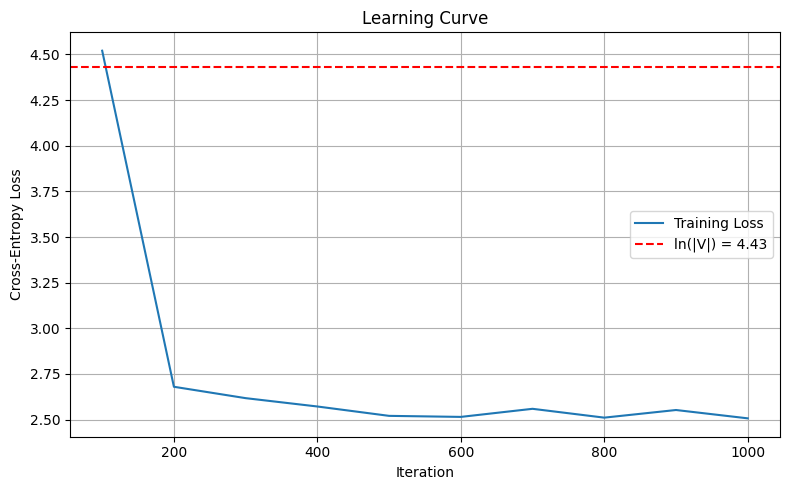

In [19]:
# Plotting learning curve
plt.figure(figsize=(8, 5))
plt.plot(range(log_interval, num_iters + 1, log_interval), loss_history, label="Training Loss")
upper_bound = math.log(vocab_size)
plt.axhline(upper_bound, color='red', linestyle='--', label=f"ln(|V|) = {upper_bound:.2f}")
plt.xlabel("Iteration")
plt.ylabel("Cross-Entropy Loss")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The Self-Attention model is more effective than LM1. It has a similar trend like LM1: starting at around ln(|V|) -> drastic decline at iter=200, and continue to decrease gradually towards the end (iter=1000). By the end, the Self-Attention model reaches a cross entropy loss of around 2.5, compared with approximately 3.0 for LM1.

This suggests that the Self-Attention model is better at using contextual information. Unlike LM1, which represents context mainly through averaged embeddings, Self-Attention can assign different weights to different previous tokens. As a result, it can capture more useful character-level dependencies and produce a lower cross entropy loss.

### Text Generation
We now generate text with the trained model

In [20]:
prompt = "This is a book. The"
generate_text(model, prompt, 2, temperature=1)

'This is a book. Therr'

In [21]:
# temp = 1.5
generate_text(model, prompt, 2, temperature=1.5)

'This is a book. Thew8'

In [22]:
# temp = 0.7
generate_text(model, prompt, 2, temperature=0.7)

'This is a book. Thetv'

In [23]:
# temp = 0.2
generate_text(model, prompt, 2, temperature=0.2)

'This is a book. Thell'

### Question: _Explain your observation._
With temp=1, the Self-Attention model generates `'This is a book. ThesC'`. It is still not making literal semantic sense. 

### Question: _Play with the temperature. What do you observe?_
When temp=0.2, the text starts to make more sense: `'The'` becomes `'Thenn'` (where `'Then'` is a real word). This suggests that the Self-Attention LM is learning some local character-level structure from the corpus. Results from temp=1.5 (`'This is a book. TheSu'`) and temp=0.7 (`'This is a book. Thegb'`) still do not produce meaningful continuations. 

One extra but important observation is that when re-running the cells above, the first three cells (1.5,1,0.7) provided different responses each time, but with temp=0.2, result is consistent across runs that always return `'Thenn'`, showing a relatively deterministic output by favouring higher-probaility characters. 